# Saudi Road Safety — Exploratory Data Analysis
### تحليل استكشافي لسلامة الطرق في المملكة العربية السعودية

**Notebook:** `01_eda.ipynb`
**Author:** Khalid Al-Dosari ([@khaliddosari](https://github.com/khaliddosari))
**Project:** [saudi-road-safety-mlops](https://github.com/khaliddosari/saudi-road-safety-mlops)

---

## Objectives

This notebook explores the processed regional panel and companion series produced by `src/data/build_panel.py`. It lays the analytical groundwork for the modeling stages (forecasting, regional risk regression, anomaly detection, clustering).

1. **Panel overview** — shape, data completeness, summary statistics
2. **National trend** 2014–2023 — with Vision 2030 road-safety milestones
3. **Regional raw vs exposure-adjusted deaths** — the Tabuk / Jazan risk paradox
4. **Year-over-year regional change** 2020 → 2024
5. **Seasonal patterns** — monthly traffic 2024 with Hajj and Ramadan markers
6. **Causes evolution** 2020 – 2023
7. **Correlation matrix** for downstream feature selection

All outputs retain bilingual region labels (English + Arabic) in the underlying dataframes so the same tables can feed the Power BI dashboard without relabeling. Chart axes use English for rendering stability; the Power BI layer handles Arabic typography.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paths resolve whether the notebook is launched from the repo root or from notebooks/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Repo root:", REPO_ROOT)
print("Processed dir exists:", PROCESSED.exists())

Repo root: c:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops
Processed dir exists: True


In [3]:
panel = pd.read_csv(PROCESSED / "regional_panel.csv")
national = pd.read_csv(PROCESSED / "national_trend.csv")
traffic = pd.read_csv(PROCESSED / "traffic_monthly.csv")
causes = pd.read_csv(PROCESSED / "causes_trend.csv")

print(f"panel      : {panel.shape}")
print(f"national   : {national.shape}")
print(f"traffic    : {traffic.shape}")
print(f"causes     : {causes.shape}")

# Arabic label lookup for anywhere we need bilingual output
REGION_AR = dict(zip(panel["region"], panel["region_ar"]))

# Curated display order: north -> south, then major urban last for emphasis
REGION_ORDER = [
    "Northern Borders", "Al-Jouf", "Tabuk", "Hail", "Qassim",
    "Madinah", "Makkah", "Eastern", "Aseer", "Al-Baha",
    "Jazan", "Najran", "Riyadh",
]

panel.head()

panel      : (65, 20)
national   : (10, 5)
traffic    : (156, 5)
causes     : (20, 3)


,region,year,injuries,deaths,severe_in_city,severe_out_city,severe_total,vehicles_new,vehicles_renewal,licenses_new,licenses_renewal,road_density_per_capita,road_density_per_area,vehicles_total,licenses_total,deaths_per_1k_vehicles,injuries_per_1k_vehicles,severe_per_1k_vehicles,fatality_ratio,region_ar
0,Al-Baha,2020,628.00,95.00,NaN,NaN,NaN,1193,16970,5843,3447,NaN,NaN,18163,9290,5.23,34.58,NaN,0.13,الباحة
1,Al-Baha,2021,565.00,92.00,NaN,NaN,388.00,1325,10724,8336,2337,NaN,NaN,12049,10673,7.64,46.89,32.20,0.14,الباحة
2,Al-Baha,2022,526.00,98.00,NaN,NaN,344.00,1041,11010,13075,1675,NaN,NaN,12051,14750,8.13,43.65,28.55,0.16,الباحة
3,Al-Baha,2023,500.00,67.00,NaN,NaN,301.00,1279,11837,11747,1454,NaN,NaN,13116,13201,5.11,38.12,22.95,0.12,الباحة
4,Al-Baha,2024,551.00,61.00,146.00,201.00,347.00,1577,12571,12512,1791,0.02,0.64,14148,14303,4.31,38.95,24.53,0.10,الباحة


## 1. Panel overview | نظرة عامة على اللوحة

We expect **13 regions × 5 years = 65 rows** with 20 columns. Completeness varies by metric — for example, severe-accident breakdowns only exist for 2021+ and in/out-of-city splits only for 2024.

In [4]:
print(f"Panel shape     : {panel.shape}")
print(f"Unique regions  : {panel['region'].nunique()}  ->  {sorted(panel['region'].unique())}")
print(f"Year range      : {panel['year'].min()} – {panel['year'].max()}")
print(f"Balanced panel  : {len(panel) == panel['region'].nunique() * panel['year'].nunique()}")

completeness = (
    panel.notna().mean().mul(100).round(1)
    .rename("pct_complete").to_frame()
    .assign(non_null=panel.notna().sum().values, total=len(panel))
)
completeness.sort_values("pct_complete")

Panel shape     : (65, 20)
Unique regions  : 13  ->  ['Al-Baha', 'Al-Jouf', 'Aseer', 'Eastern', 'Hail', 'Jazan', 'Madinah', 'Makkah', 'Najran', 'Northern Borders', 'Qassim', 'Riyadh', 'Tabuk']
Year range      : 2020 – 2024
Balanced panel  : True


,pct_complete,non_null,total
severe_out_city,20.00,13,65
severe_in_city,20.00,13,65
road_density_per_area,20.00,13,65
road_density_per_capita,20.00,13,65
severe_total,80.00,52,65
severe_per_1k_vehicles,80.00,52,65
deaths,100.00,65,65
injuries,100.00,65,65
vehicles_new,100.00,65,65
year,100.00,65,65


In [5]:
summary_cols = [
    "injuries", "deaths", "severe_total",
    "vehicles_total", "licenses_total",
    "deaths_per_1k_vehicles", "injuries_per_1k_vehicles",
    "severe_per_1k_vehicles", "fatality_ratio",
]
panel[summary_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
injuries,65.00,"1,901.51","2,348.82",78.00,"1,055.00","9,143.00"
deaths,65.00,346.62,320.30,45.00,223.00,"1,157.00"
severe_total,52.00,"1,325.56","1,648.78",98.00,679.00,"6,139.00"
vehicles_total,65.00,"149,901.37","209,833.86","9,585.00","40,709.00","829,033.00"
licenses_total,65.00,"87,340.18","114,243.44","8,975.00","36,282.00","516,285.00"
deaths_per_1k_vehicles,65.00,4.25,2.16,1.05,4.31,9.65
injuries_per_1k_vehicles,65.00,20.23,13.76,2.86,17.98,54.97
severe_per_1k_vehicles,52.00,14.14,9.21,3.64,12.20,36.57
fatality_ratio,65.00,0.20,0.08,0.09,0.18,0.52


## 2. National trend with Vision 2030 milestones | الاتجاه الوطني ومعالم رؤية 2030

National fatality and injury series 2014 – 2023, from the GASTAT Open Data Portal. Annotated with:

- **2016** — Vision 2030 launched (April 2016); pre-reform fatality peak (~28.3 / 100k).
- **2018** — Saher expansion and tightened enforcement; first sustained drop below 20 / 100k.
- **2020** — COVID-19 mobility collapse drove a one-off structural break (−30% deaths YoY).
- **2030 target** — Saudi Arabia's Vision 2030 + WHO Decade of Action commitment: **< 10 road deaths per 100,000 population**.

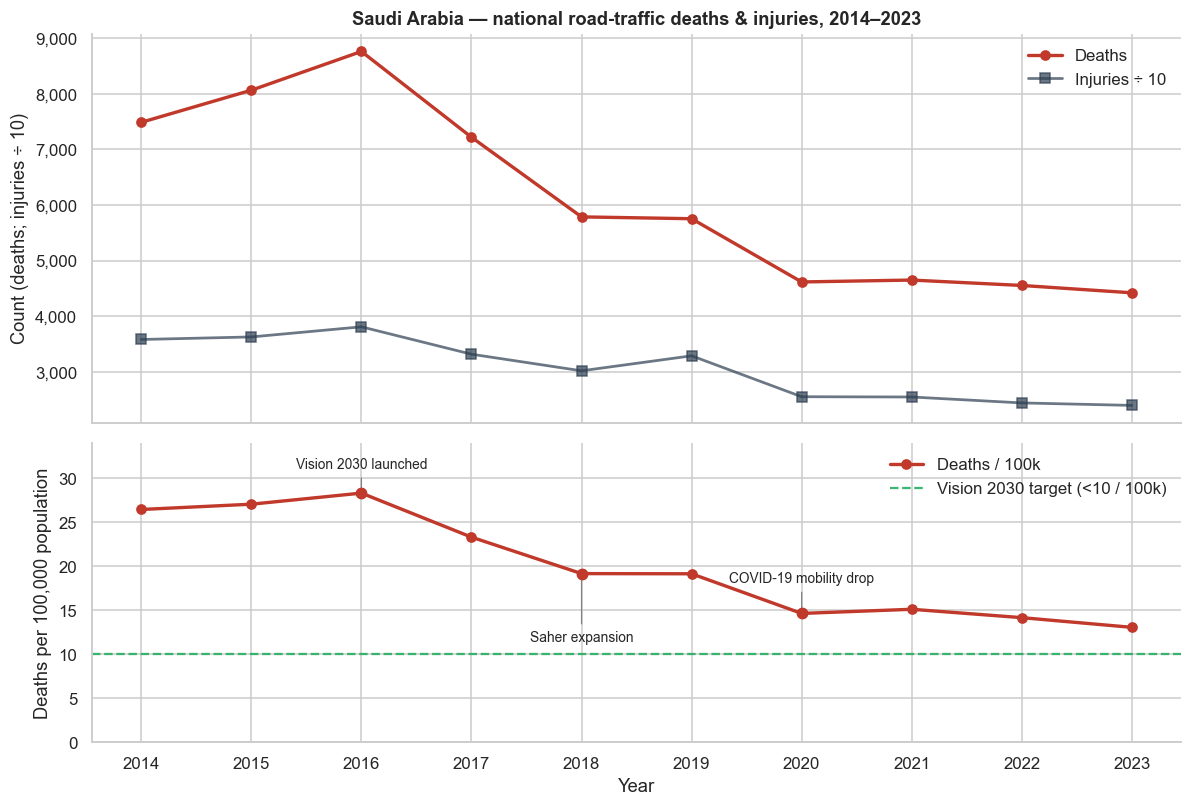

Peak death rate  : 28.3 / 100k in 2016
Latest death rate: 13.1 / 100k in 2023  (−54% vs peak)
Gap to 2030 goal : 3.1 / 100k remaining


In [6]:
nat = national.dropna(subset=["year"]).sort_values("year").copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True,
                               gridspec_kw={"height_ratios": [1.3, 1]})

# Absolute counts
ax1.plot(nat["year"], nat["national_deaths"], marker="o", lw=2.2,
         color="#c0392b", label="Deaths")
ax1.plot(nat["year"], nat["national_injuries"] / 10, marker="s", lw=1.8,
         color="#2c3e50", alpha=0.7, label="Injuries ÷ 10")
ax1.set_ylabel("Count (deaths; injuries ÷ 10)")
ax1.set_title("Saudi Arabia — national road-traffic deaths & injuries, 2014–2023")
ax1.legend(loc="upper right", frameon=False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Rates per 100k
ax2.plot(nat["year"], nat["death_rate_per_100k"], marker="o", lw=2.2,
         color="#c0392b", label="Deaths / 100k")
ax2.axhline(10, ls="--", color="#27ae60", lw=1.5, alpha=0.9,
            label="Vision 2030 target (<10 / 100k)")

# Milestone annotations tied to the death-rate line
milestones = [
    (2016, "Vision 2030 launched", 8),
    (2018, "Saher expansion", -22),
    (2020, "COVID-19 mobility drop", 10),
]
for yr, label, dy in milestones:
    y = nat.loc[nat["year"] == yr, "death_rate_per_100k"].squeeze()
    ax2.annotate(label, xy=(yr, y), xytext=(yr, y + dy * 0.35),
                 ha="center", fontsize=9,
                 arrowprops=dict(arrowstyle="-", color="grey", lw=0.8))
    ax2.scatter([yr], [y], s=45, color="#c0392b", zorder=5)

ax2.set_ylabel("Deaths per 100,000 population")
ax2.set_xlabel("Year")
ax2.set_ylim(0, 34)
ax2.legend(loc="upper right", frameon=False)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

latest = nat.iloc[-1]
peak = nat.loc[nat["death_rate_per_100k"].idxmax()]
print(f"Peak death rate  : {peak['death_rate_per_100k']:.1f} / 100k in {int(peak['year'])}")
print(f"Latest death rate: {latest['death_rate_per_100k']:.1f} / 100k in {int(latest['year'])}  "
      f"(−{(1 - latest['death_rate_per_100k']/peak['death_rate_per_100k'])*100:.0f}% vs peak)")
print(f"Gap to 2030 goal : {latest['death_rate_per_100k'] - 10:.1f} / 100k remaining")

## 3. Regional raw vs exposure-adjusted deaths (2024) | مقارنة الوفيات المطلقة بالمعدّلة

Raw counts heavily reward populous regions (Riyadh, Makkah, Eastern). Normalizing by registered-vehicle exposure reveals a different map: **sparsely populated but long-highway regions (Tabuk, Jazan, Al-Baha, Najran) can be structurally riskier per trip than the urban core.** This is the "risk paradox" the LightGBM model in stage 3 is designed to explain.

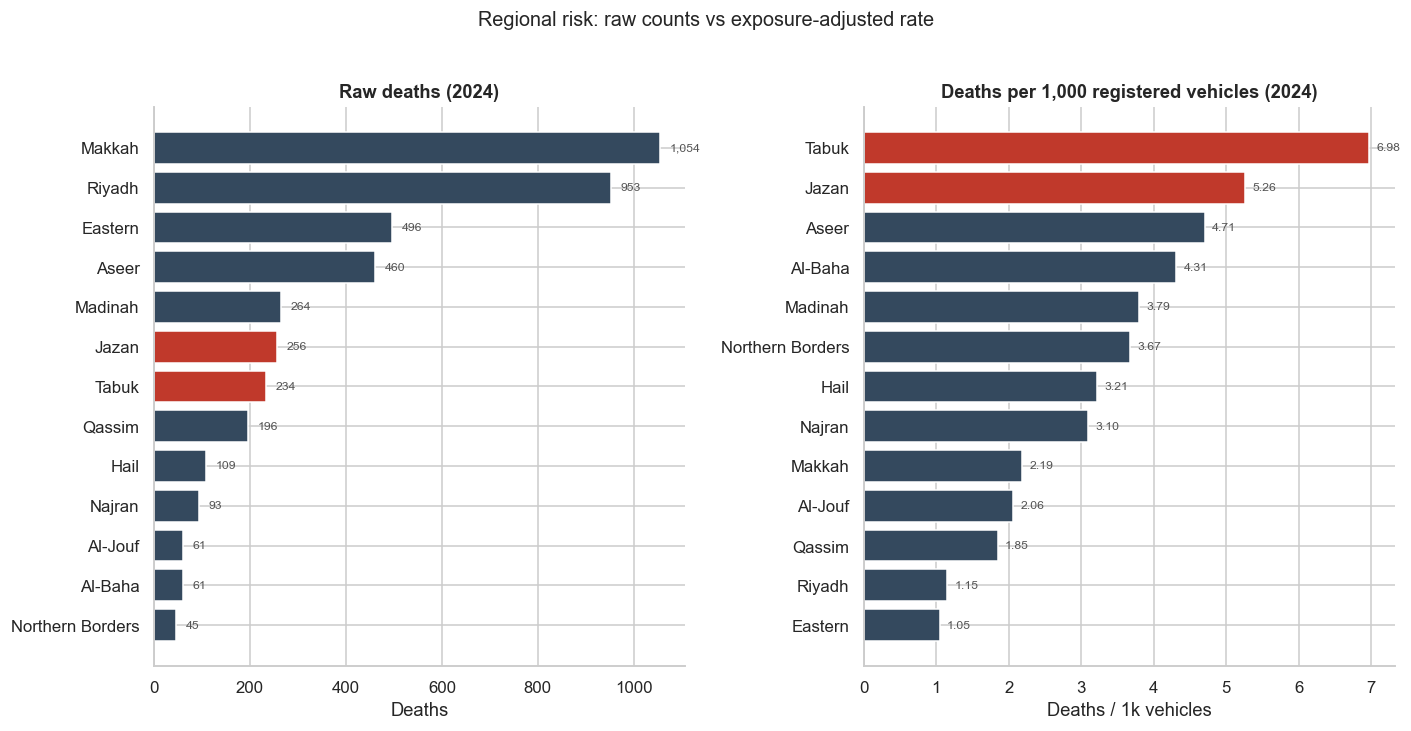

,region,region_ar,deaths,rank_raw,deaths_per_1k_vehicles,rank_adjusted,rank_shift
0,Tabuk,تبوك,234,7,6.98,1,6
1,Jazan,جازان,256,6,5.26,2,4
2,Aseer,عسير,460,4,4.71,3,1
3,Al-Baha,الباحة,61,11,4.31,4,7
4,Madinah,المدينة المنورة,264,5,3.79,5,0
5,Northern Borders,الحدود الشمالية,45,13,3.67,6,7
6,Hail,حائل,109,9,3.21,7,2
7,Najran,نجران,93,10,3.10,8,2
8,Makkah,مكة المكرمة,1054,1,2.19,9,-8
9,Al-Jouf,الجوف,61,11,2.06,10,1


In [12]:
p24 = panel.query("year == 2024").copy()
p24_raw = p24.sort_values("deaths", ascending=True)
p24_adj = p24.sort_values("deaths_per_1k_vehicles", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

# --- Raw deaths -----------------------------------------------------------
bar_colors_raw = ["#c0392b" if r in ("Tabuk", "Jazan") else "#34495e"
                  for r in p24_raw["region"]]
axes[0].barh(p24_raw["region"], p24_raw["deaths"], color=bar_colors_raw)
axes[0].set_title("Raw deaths (2024)")
axes[0].set_xlabel("Deaths")
for y, (r, v) in enumerate(zip(p24_raw["region"], p24_raw["deaths"])):
    axes[0].text(v + 20, y, f"{int(v):,}", va="center", fontsize=8, color="#555")

# --- Exposure-adjusted -----------------------------------------------------
bar_colors_adj = ["#c0392b" if r in ("Tabuk", "Jazan") else "#34495e"
                  for r in p24_adj["region"]]
axes[1].barh(p24_adj["region"], p24_adj["deaths_per_1k_vehicles"], color=bar_colors_adj)
axes[1].set_title("Deaths per 1,000 registered vehicles (2024)")
axes[1].set_xlabel("Deaths / 1k vehicles")
for y, (r, v) in enumerate(zip(p24_adj["region"], p24_adj["deaths_per_1k_vehicles"])):
    axes[1].text(v + 0.1, y, f"{v:.2f}", va="center", fontsize=8, color="#555")

fig.suptitle("Regional risk: raw counts vs exposure-adjusted rate",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Rank-shift table: where a region sits on each ladder
rank_tbl = pd.DataFrame({
    "region": p24["region"],
    "region_ar": p24["region_ar"],
    "deaths": p24["deaths"].astype(int),
    "rank_raw": p24["deaths"].rank(ascending=False).astype(int),
    "deaths_per_1k_vehicles": p24["deaths_per_1k_vehicles"].round(2),
    "rank_adjusted": p24["deaths_per_1k_vehicles"].rank(ascending=False).astype(int),
})
rank_tbl["rank_shift"] = rank_tbl["rank_raw"] - rank_tbl["rank_adjusted"]
rank_tbl.sort_values("rank_adjusted").reset_index(drop=True)

## 4. Year-over-year regional change 2020 → 2024 | التغير الإقليمي من 2020 إلى 2024

Compares fatality counts and exposure-adjusted rates at the two endpoints of the panel. Regions with negative `deaths_pct_change` improved; positive means deterioration. Because vehicle stocks grew everywhere, adjusted rates usually fall faster than raw counts.

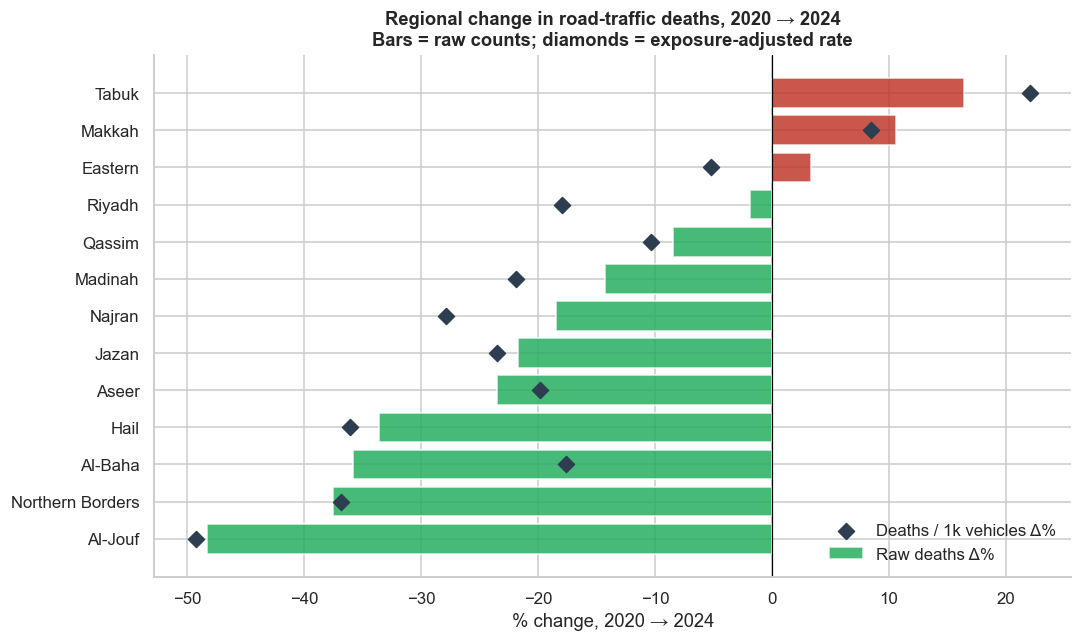

,region_ar,deaths_2020,deaths_2024,deaths_pct_change,rate_2020,rate_2024,rate_pct_change
region,,,,,,,
Al-Jouf,الجوف,118.00,61.00,-48.31,4.07,2.06,-49.23
Northern Borders,الحدود الشمالية,72.00,45.00,-37.50,5.81,3.67,-36.79
Al-Baha,الباحة,95.00,61.00,-35.79,5.23,4.31,-17.57
Hail,حائل,164.00,109.00,-33.54,5.03,3.21,-36.09
Aseer,عسير,601.00,460.00,-23.46,5.87,4.71,-19.79
Jazan,جازان,327.00,256.00,-21.71,6.87,5.26,-23.46
Najran,نجران,114.00,93.00,-18.42,4.30,3.10,-27.89
Madinah,المدينة المنورة,308.00,264.00,-14.29,4.86,3.79,-21.88
Qassim,القصيم,214.00,196.00,-8.41,2.06,1.85,-10.33


In [8]:
yoy_cols = ["region", "region_ar", "deaths", "deaths_per_1k_vehicles"]
p20 = panel.query("year == 2020")[yoy_cols].set_index("region")
p24i = panel.query("year == 2024")[yoy_cols].set_index("region")

yoy = pd.DataFrame({
    "region_ar": p20["region_ar"],
    "deaths_2020": p20["deaths"],
    "deaths_2024": p24i["deaths"],
    "deaths_pct_change": (p24i["deaths"] / p20["deaths"] - 1) * 100,
    "rate_2020": p20["deaths_per_1k_vehicles"],
    "rate_2024": p24i["deaths_per_1k_vehicles"],
    "rate_pct_change": (p24i["deaths_per_1k_vehicles"] / p20["deaths_per_1k_vehicles"] - 1) * 100,
}).sort_values("deaths_pct_change")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#27ae60" if v < 0 else "#c0392b" for v in yoy["deaths_pct_change"]]
ax.barh(yoy.index, yoy["deaths_pct_change"], color=colors, alpha=0.85,
        label="Raw deaths Δ%")
ax.scatter(yoy["rate_pct_change"], yoy.index, marker="D", s=55,
           color="#2c3e50", zorder=5, label="Deaths / 1k vehicles Δ%")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("% change, 2020 → 2024")
ax.set_title("Regional change in road-traffic deaths, 2020 → 2024\n"
             "Bars = raw counts; diamonds = exposure-adjusted rate")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

yoy.round(2)

## 5. Seasonal traffic patterns (2024) | الأنماط الموسمية — حركة المرور ٢٠٢٤

Monthly inter-city vehicle counts from GASTAT sensor points, 2024. Overlaid:

- **Ramadan 2024** — March 11 → April 9 (1445 H).
- **Hajj 2024** — June 14 → 19 (1445 H), peak Makkah / Madinah pilgrim flow.

Makkah and Madinah are the clearest religious-travel signals; Riyadh and Eastern show a summer-travel/leave pattern; northern and southern peripheries dominate early winter.

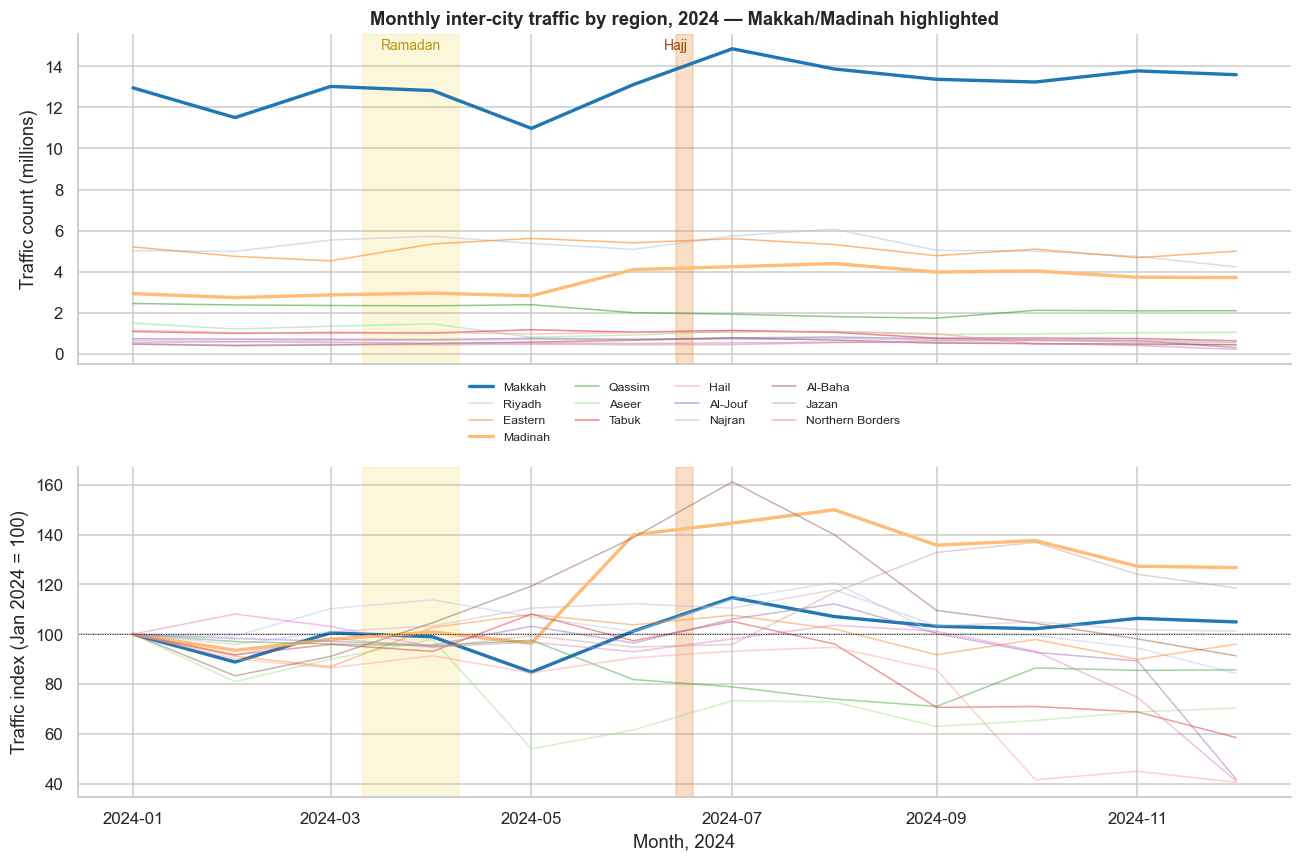

Makkah traffic index (Jan=100):
month
1    100.00
2     88.80
3    100.50
4     99.00
5     84.80
6    101.20
7    114.70
8    107.10
9    103.20
10   102.20
11   106.40
12   104.90


In [9]:
tm = traffic.copy()
tm["date"] = pd.to_datetime(dict(year=tm["year"], month=tm["month"], day=1))

# Index each region to Jan 2024 = 100 so curves are comparable
base = (tm.sort_values(["region", "date"])
          .groupby("region")["traffic_count"].transform("first"))
tm["traffic_index"] = tm["traffic_count"] / base * 100

# Ordered by 2024 total so the legend reads big-to-small
region_totals = tm.groupby("region")["traffic_count"].sum().sort_values(ascending=False)
ordered_regions = region_totals.index.tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

palette = sns.color_palette("tab20", n_colors=len(ordered_regions))

# --- Absolute traffic -----------------------------------------------------
for color, region in zip(palette, ordered_regions):
    sub = tm[tm["region"] == region].sort_values("date")
    lw = 2.2 if region in ("Makkah", "Madinah") else 1.0
    alpha = 1.0 if region in ("Makkah", "Madinah") else 0.55
    ax1.plot(sub["date"], sub["traffic_count"] / 1e6,
             label=region, color=color, lw=lw, alpha=alpha)
ax1.set_ylabel("Traffic count (millions)")
ax1.set_title("Monthly inter-city traffic by region, 2024 — Makkah/Madinah highlighted")
ax1.legend(ncol=4, fontsize=8, frameon=False, loc="upper center",
           bbox_to_anchor=(0.5, -0.02))

# --- Indexed (Jan = 100) -------------------------------------------------
for color, region in zip(palette, ordered_regions):
    sub = tm[tm["region"] == region].sort_values("date")
    lw = 2.2 if region in ("Makkah", "Madinah") else 1.0
    alpha = 1.0 if region in ("Makkah", "Madinah") else 0.45
    ax2.plot(sub["date"], sub["traffic_index"],
             color=color, lw=lw, alpha=alpha)
ax2.axhline(100, color="black", lw=0.6, ls=":")
ax2.set_ylabel("Traffic index (Jan 2024 = 100)")
ax2.set_xlabel("Month, 2024")

# Religious-travel windows on both axes
ramadan = (pd.Timestamp("2024-03-11"), pd.Timestamp("2024-04-09"))
hajj = (pd.Timestamp("2024-06-14"), pd.Timestamp("2024-06-19"))
for ax in (ax1, ax2):
    ax.axvspan(*ramadan, color="#f1c40f", alpha=0.15)
    ax.axvspan(*hajj, color="#e67e22", alpha=0.25)

# Window labels (only on the top axis so they don't double up)
ax1.text(ramadan[0] + (ramadan[1] - ramadan[0]) / 2,
         ax1.get_ylim()[1] * 0.95, "Ramadan",
         ha="center", fontsize=9, color="#b7950b")
ax1.text(hajj[0], ax1.get_ylim()[1] * 0.95, "Hajj",
         ha="center", fontsize=9, color="#a04000")

plt.tight_layout()
plt.show()

# Religious-travel signal: Makkah growth during Hajj vs its own Jan baseline
makkah = tm.query("region == 'Makkah'").sort_values("month").set_index("month")
print("Makkah traffic index (Jan=100):")
print(makkah["traffic_index"].round(1).to_string())

## 6. Causes evolution 2020 – 2023 | تطور أسباب الحوادث

National totals by GASTAT's normalized cause taxonomy. Share-of-total is more informative than absolute count, since reporting volumes grew substantially after 2021.

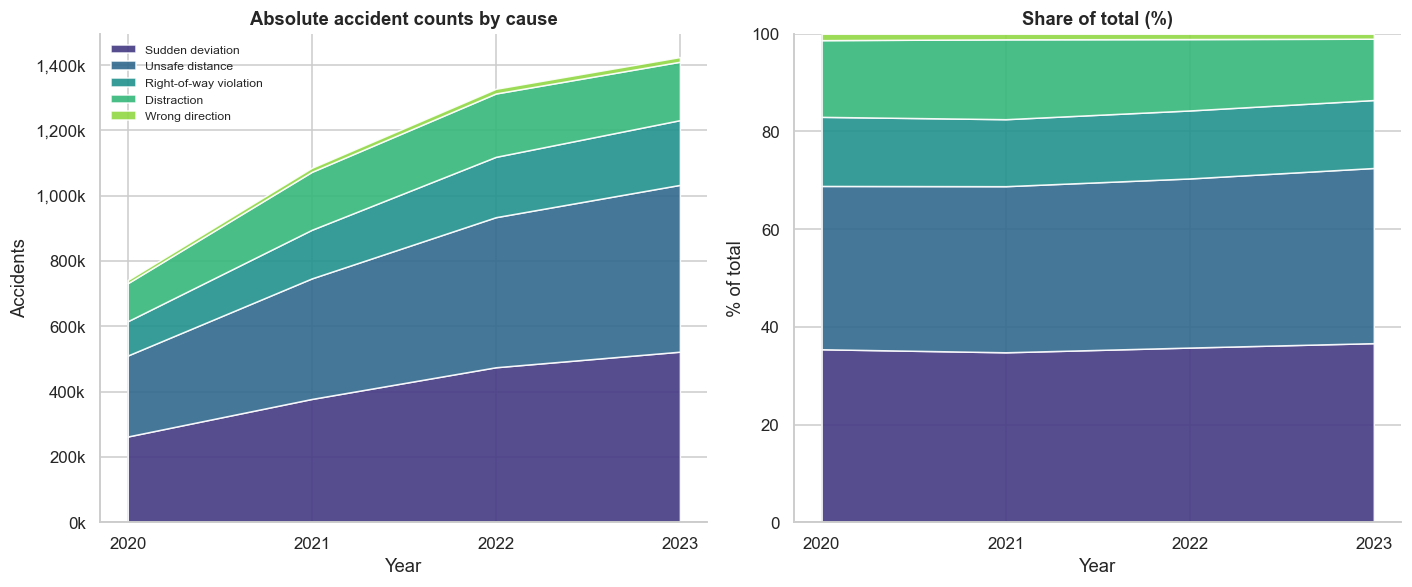

Cause share by year (%):


cause,Sudden deviation,Unsafe distance,Right-of-way violation,Distraction,Wrong direction
year,,,,,
2020,35.40,33.40,14.10,15.70,1.30
2021,34.80,34.00,13.70,16.30,1.10
2022,35.80,34.60,13.90,14.60,1.10
2023,36.70,35.80,13.90,12.60,1.00


In [10]:
causes_wide = (causes.pivot_table(index="year", columns="cause",
                                  values="accidents", aggfunc="sum")
                       .sort_index())
causes_share = causes_wide.div(causes_wide.sum(axis=1), axis=0) * 100

# Order causes by 2023 share (largest at bottom of stack)
order = causes_share.loc[causes_share.index.max()].sort_values(ascending=False).index.tolist()
causes_wide = causes_wide[order]
causes_share = causes_share[order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

palette = sns.color_palette("viridis", n_colors=len(order))

ax1.stackplot(causes_wide.index, causes_wide[order].T,
              labels=order, colors=palette, alpha=0.9)
ax1.set_title("Absolute accident counts by cause")
ax1.set_ylabel("Accidents")
ax1.set_xlabel("Year")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1e3):,}k"))
ax1.legend(loc="upper left", fontsize=8, frameon=False)

ax2.stackplot(causes_share.index, causes_share[order].T,
              labels=order, colors=palette, alpha=0.9)
ax2.set_title("Share of total (%)")
ax2.set_ylabel("% of total")
ax2.set_xlabel("Year")
ax2.set_ylim(0, 100)

for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

print("Cause share by year (%):")
causes_share.round(1)

## 7. Correlation matrix | مصفوفة الارتباط

Pearson correlations across numeric panel features. This screens which inputs carry distinct information for the regional risk model (stage 3). Near-duplicate columns (e.g. `vehicles_total` and `vehicles_renewal`) will be collapsed in feature engineering.

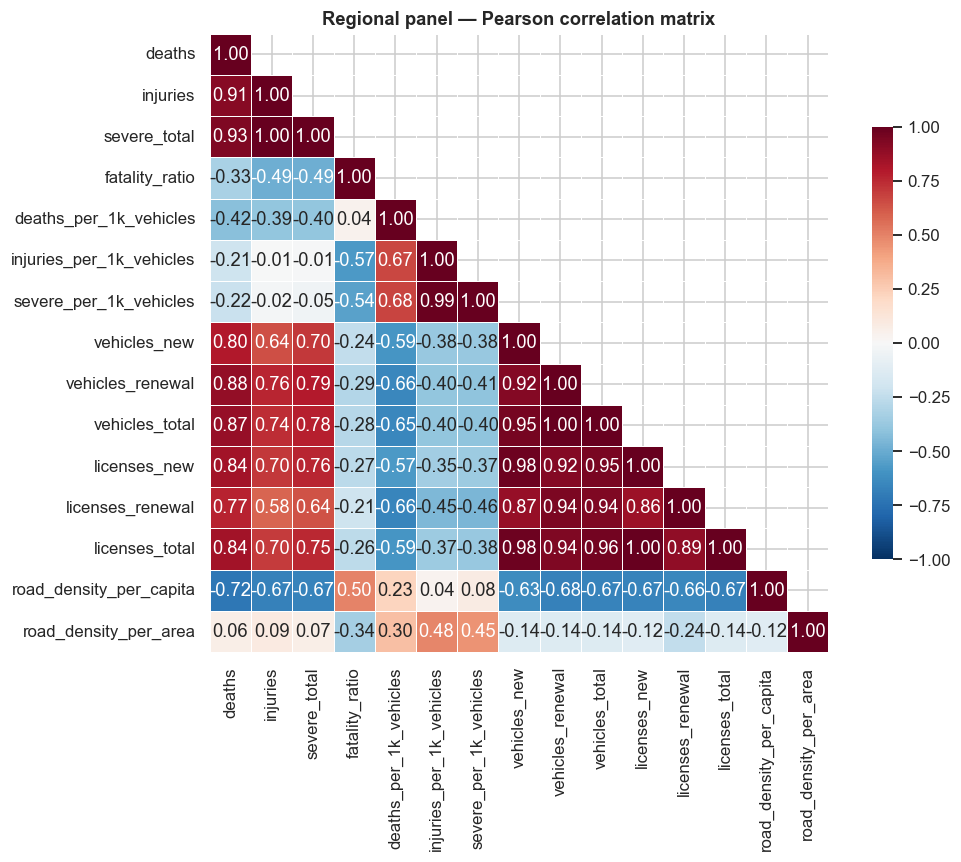

Strongest correlates of deaths_per_1k_vehicles:
licenses_renewal           -0.66
vehicles_renewal           -0.66
vehicles_total             -0.65
licenses_total             -0.59
vehicles_new               -0.59
fatality_ratio              0.04
road_density_per_capita     0.23
road_density_per_area       0.30
injuries_per_1k_vehicles    0.67
severe_per_1k_vehicles      0.68


In [11]:
corr_cols = [
    "deaths", "injuries", "severe_total", "fatality_ratio",
    "deaths_per_1k_vehicles", "injuries_per_1k_vehicles", "severe_per_1k_vehicles",
    "vehicles_new", "vehicles_renewal", "vehicles_total",
    "licenses_new", "licenses_renewal", "licenses_total",
    "road_density_per_capita", "road_density_per_area",
]
corr_cols = [c for c in corr_cols if c in panel.columns]
corr = panel[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Regional panel — Pearson correlation matrix")
plt.tight_layout()
plt.show()

# Top positive & negative correlates of deaths_per_1k_vehicles (risk signal)
target = "deaths_per_1k_vehicles"
target_corr = corr[target].drop(target).sort_values()
print(f"Strongest correlates of {target}:")
print(pd.concat([target_corr.head(5), target_corr.tail(5)]).round(3).to_string())

## Key findings & next steps | أهم النتائج والخطوات التالية

**Findings — to carry into modeling**

1. **Panel is balanced** (13 × 5 = 65 rows). Completeness is full for accidents, vehicles, licenses; severe-accident breakdowns are partial (2021+); road density is 2024-only.
2. **National trajectory is improving but off target.** Death rate fell from ~28 / 100k (2016) to ~13 / 100k (2023) — roughly a 54% drop vs peak, but still 3 points above the Vision 2030 < 10 / 100k goal. The 2020 COVID break should be modeled explicitly (regime shift / intervention term) rather than treated as trend.
3. **Raw vs exposure-adjusted ranks diverge sharply.** Tabuk and Jazan rank far higher on deaths-per-1k-vehicles than on raw deaths; Riyadh is the opposite. This confirms the core thesis of the project — policy targeting should use exposure-adjusted risk, not raw counts.
4. **All regions improved 2020 → 2024** on exposure-adjusted rates, but some regressed on raw counts because vehicle stocks grew faster than fatalities fell. The regional LightGBM model will need both as signals.
5. **Seasonality is region-specific.** Makkah and Madinah show clear Hajj/Umrah pulses; Riyadh and Eastern Province show a summer-vacation pattern; northern/southern peripheries peak in early winter. A region-specific STL + Isolation Forest (stage 4) is justified over a single global model.
6. **Accident causes concentrate.** "Unsafe distance" and "Sudden deviation" together account for the majority of reported accidents every year — a single behavioral cluster that policy interventions can plausibly target.
7. **Feature selection:** `vehicles_total`, `licenses_total`, and their `_new`/`_renewal` components are strongly collinear. Keep totals plus one of the news (as a churn proxy) and drop the rest to control VIF for LightGBM.

**Next in the roadmap**

- `notebooks/02_forecasting.ipynb` — Prophet + SARIMA ensemble on `national_trend.csv`, with 2020 as an explicit intervention.
- `notebooks/03_regional_risk.ipynb` — LightGBM on the panel, SHAP values by region.
- `notebooks/04_anomaly.ipynb` — STL decomposition + Isolation Forest on `traffic_monthly.csv`.
- `notebooks/05_clustering.ipynb` — K-Means on standardized regional features, silhouette validation.
- `src/api/` — FastAPI endpoints wrapping the above models; Dockerized.
- `powerbi/` — bilingual dashboard consuming the processed CSVs.